Data Mahasiswa
           NIM                Name  KUIS  UTS  UAS  Nilai Grade
0   2355301103      M. Fitra Azizi    90   82   87  86.31     A
1       120001            John Doe    85   78   90  84.44     A
2       120005          Jane Smith    92   88   94  91.38     A
3       120017     Michael Johnson    48   65   56  56.41     C
4       120018         Emily Brown    90   85   88  87.65     A
5       120022     Daniel Martinez    75   80   77  77.35    AB
6       120024        Sarah Wilson    88   70   65  74.01     B
7       120025        David Garcia    75   70   75  73.35     B
8       120027         Jessica Lee    95   91   96  94.03     A
9       120034       Matthew Davis    79   84   78  80.30    AB
10      120035  Jennifer Rodriguez    42   48   63  51.33     C
11      120036       Andrew Taylor    53   64   59  58.73     C
12      120038    Amanda Hernandez    91   95   90  91.97     A
13      120039   Christopher Clark    76   81   75  77.30    AB
14      120046  Elizabeth

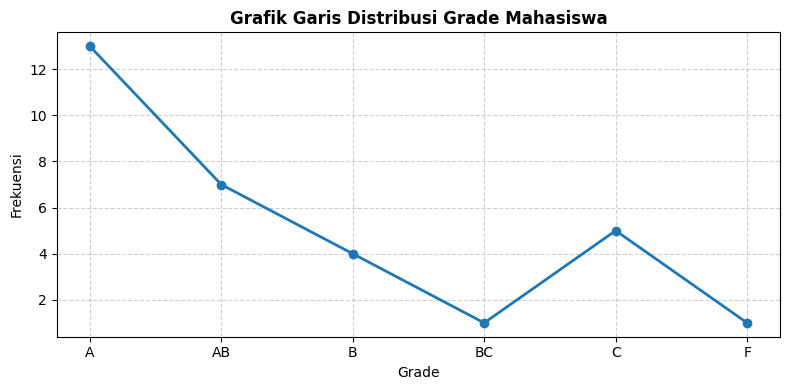

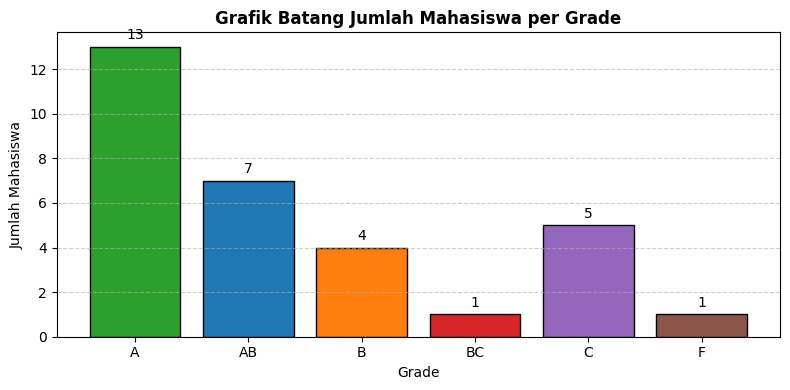

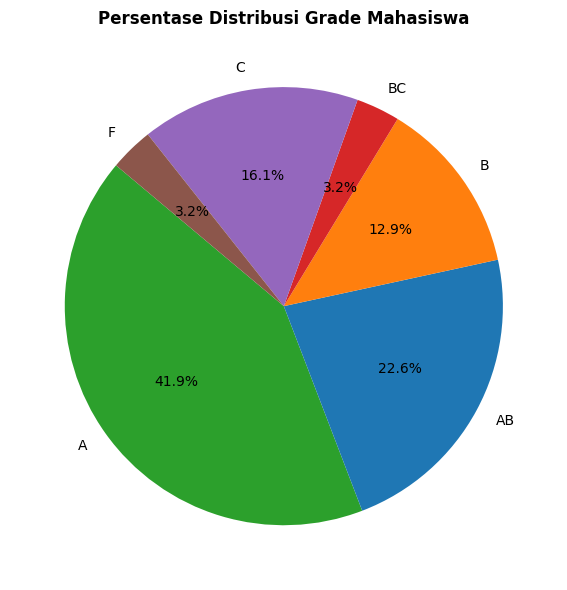


Ringkasan Statistika Deskriptif
Jumlah Mahasiswa     31.000
Mean                 76.547
Median               79.300
Modus                77.300
Minimum              46.010
Q1 (25%)             68.800
Q2 (50%)             79.300
Q3 (75%)             86.800
Maximum              94.030
Range                48.020
Variance            178.587
Std. Deviation       13.364
Standard Error        2.400
Skewness             -0.718
Kurtosis             -0.455
dtype: float64


In [7]:
import matplotlib.pyplot as plt
import pandas as pd

# Tabel
path = "Fitra.xlsx"
data = pd.read_excel(path)

print("Data Mahasiswa")
print(data.head(30))

# Penyesuaian nama kolom (otomatis mengubah nama kolom ke standar jika perlu)
col_nilai = "Final Score" if "Final Score" in data.columns else "Nilai"
col_grade = "Grade"

# Tabel Frekuensi
datafrq = pd.crosstab(
    index=data[col_grade], columns="Frekuensi"
).reindex(["A", "AB", "B", "BC", "C", "F"])
datafrq["Persentase (%)"] = (
    datafrq["Frekuensi"] / datafrq["Frekuensi"].sum()
) * 100

print("\nTabel Frekuensi Grade")
print(datafrq)

# Data Visual
colors = ["#2ca02c", "#1f77b4", "#ff7f0e", "#d62728", "#9467bd", "#8c564b"]

# Grafik Garis (Line Chart)
plt.figure(figsize=(8, 4))
plt.plot(
    datafrq.index,
    datafrq["Frekuensi"],
    marker="o",
    color="#1f77b4",
    linewidth=2,
    markersize=6,
)
plt.title(
    "Grafik Garis Distribusi Grade Mahasiswa", fontsize=12, fontweight="bold"
)
plt.xlabel("Grade")
plt.ylabel("Frekuensi")
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

# Grafik Batang (Bar Chart)
plt.figure(figsize=(8, 4))
bars = plt.bar(
    datafrq.index, datafrq["Frekuensi"], color=colors, edgecolor="black"
)
plt.title(
    "Grafik Batang Jumlah Mahasiswa per Grade", fontsize=12, fontweight="bold"
)
plt.xlabel("Grade")
plt.ylabel("Jumlah Mahasiswa")
plt.grid(axis="y", linestyle="--", alpha=0.6)

for bar in bars:
    yval = bar.get_height()
    if not pd.isna(yval):
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            yval + 0.2,
            int(yval),
            ha="center",
            va="bottom",
        )

plt.tight_layout()
plt.show()

# Grafik Lingkaran (Pie Chart)
plt.figure(figsize=(6, 6))
plt.pie(
    datafrq["Frekuensi"].fillna(0),
    labels=datafrq.index,
    autopct="%1.1f%%",
    startangle=140,
    colors=colors,
)
plt.title(
    "Persentase Distribusi Grade Mahasiswa", fontsize=12, fontweight="bold"
)
plt.tight_layout()
plt.show()

# Statistika Deskriptif
nilai = data[col_nilai]
stats = pd.Series(
    {
        "Jumlah Mahasiswa": nilai.count(),
        "Mean": nilai.mean(),
        "Median": nilai.median(),
        "Modus": nilai.mode()[0],
        "Minimum": nilai.min(),
        "Q1 (25%)": nilai.quantile(0.25),
        "Q2 (50%)": nilai.median(),
        "Q3 (75%)": nilai.quantile(0.75),
        "Maximum": nilai.max(),
        "Range": nilai.max() - nilai.min(),
        "Variance": nilai.var(),
        "Std. Deviation": nilai.std(),
        "Standard Error": nilai.sem(),
        "Skewness": nilai.skew(),
        "Kurtosis": nilai.kurt(),
    }
)

print("\nRingkasan Statistika Deskriptif")
print(stats.round(3))